In [1]:
import torch
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from model import ScalingLaw, GetAsymptVar, SampleAlpha
from model_general import ScalingLaw as ScalingLawGeneral
from constants import lower_bounds, test_models, delete_models, Y_names_tidy, Y_names, B, lrs, scheduler_factors, reps, n_epochs, random_seed
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from concurrent.futures import ThreadPoolExecutor, as_completed

K = 4
eps = 1e-3
Y_names = Y_names[0]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Data

In [2]:
# Loading
df = pd.merge(pd.read_csv('data/df_full_v1.csv').drop('Unnamed: 0', axis=1),
              pd.read_csv('data/df_full_v2.csv').drop('Unnamed: 0', axis=1), 
              on=['model', 'family', 'size', 'tokens', 'flops'], how='outer')

# Creating data objects
Y = np.array(df.loc[:,Y_names])
Y = np.clip(Y, a_min=eps, a_max=1-eps)
        
X = np.log(np.array(df.loc[:,['size','tokens']]))
X = np.hstack((X,(X[:,0]*X[:,1])[:,None]))

D = np.array(pd.get_dummies(df.family)).astype(int)
I = np.ones(shape=(D.shape[0],1))
C = np.array([lower_bounds[s] for s in Y_names]).reshape((1,-1))

Training models

In [3]:
test_models.keys()

dict_keys(['meta-llama-3', 'qwen2', 'yi-1.5', 'olmo', 'smollm', 'gemma2'])

In [5]:
reps = 2
pred_models = {}

for fam in tqdm(test_models.keys()):
    train_idx = [m not in delete_models[fam] for m in df.model]
    test_idx = [m in test_models[fam] for m in df.model]

    mu = np.mean(X[train_idx], axis=0, keepdims=True)
    std = np.std(X[train_idx], axis=0, keepdims=True)

    X_train = (X[train_idx]-mu)/std
    Y_train = Y[train_idx]
    D_train = D[train_idx]
    
    pred_models[fam] = {}
    pred_models[fam]['mu'] = mu
    pred_models[fam]['std'] = std
    pred_models[fam]['X_test'] = (X[test_idx]-mu)/std
    pred_models[fam]['Y_test'] = Y[test_idx]
    pred_models[fam]['D_test'] = D[test_idx]
    pred_models[fam]['X_train'] = X_train
    pred_models[fam]['Y_train'] = Y_train
    pred_models[fam]['D_train'] = D_train

    # Model 1
    pred_models[fam]['model'] = ScalingLaw(K)
    pred_models[fam]['model'].fit(X = X_train,
                                  Y = Y_train,
                                  D = D_train,
                                  C = C,
                                  B = B,
                                  lrs = lrs,
                                  scheduler_factors = scheduler_factors,
                                  reps = reps,
                                  n_epochs = n_epochs,    
                                  verbose = False,
                                  device = device)

    # Model 2
    pred_models[fam]['model-general'] = ScalingLawGeneral(K)
    pred_models[fam]['model-general'].fit(X_mean = X_train,
                                          Y = Y_train,
                                          D = D_train,
                                          C = C,
                                          X_phi = X_train,
                                          B = B,
                                          lrs = lrs,
                                          scheduler_factors = scheduler_factors,
                                          reps = reps,
                                          n_epochs = n_epochs,    
                                          verbose = False,
                                          device = device)
        
    np.save(f"models/prediction_intervals/models_data.npy", pred_models)

  0%|          | 0/6 [00:00<?, ?it/s]

Different lrs:   0%|          | 0/3 [00:00<?, ?it/s]

Different scheduler factors:   0%|          | 0/2 [00:00<?, ?it/s]

Reps:   0%|          | 0/2 [00:00<?, ?it/s]


KeyboardInterrupt



Results

In [7]:
fam = 'meta-llama-3'

In [8]:
pred_models = np.load("models/prediction_intervals/models_data.npy", allow_pickle=True).item()

In [9]:
pred_models[fam].keys()

dict_keys(['mu', 'std', 'X_test', 'Y_test', 'model', 'model-general', 'D_test', 'X_train', 'Y_train', 'D_train'])

In [9]:
pred_models[fam]['model']

In [10]:
train_idx = [m not in delete_models[fam] for m in df.model]
test_idx = [m in test_models[fam] for m in df.model]

mu = np.mean(X[train_idx], axis=0, keepdims=True)
std = np.std(X[train_idx], axis=0, keepdims=True)

X_train = (X[train_idx]-mu)/std
Y_train = Y[train_idx]
D_train = D[train_idx]

fine-tuning:   0%|          | 0/5000 [00:00<?, ?it/s]

grad norm: 117.11425018310547
grad norm: 6.365921974182129
grad norm: 1.458201289176941
grad norm: 0.3804211914539337
grad norm: 0.07594956457614899


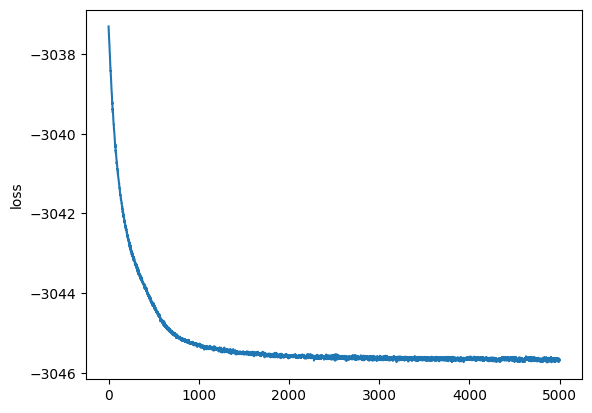

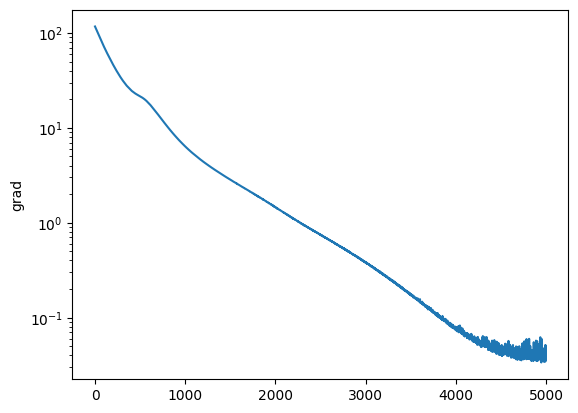

CPU times: user 57min 30s, sys: 1h 14min 10s, total: 2h 11min 40s
Wall time: 16min 25s


/workspace/statistical-scaling-law/model.py:705: ComplexWarning: Casting complex values to real discards the imaginary part
  return [{'min_eigenvalue':np.min(torch.linalg.eig(V).eigenvalues.cpu().numpy().astype(float)),


In [11]:
%%time
cov = GetAsymptVar(X=X_train, Y=Y_train, D=D_train, C=C,
                   model=pred_models[fam]['model'], K=K, B=B,
                   n_epochs = 5000, device=device)

In [12]:
cov

[{'min_eigenvalue': np.float64(3.2924127945520774e-05),
  'V': array([[ 0.09578227, -0.01744095, -0.00260221, ..., -0.05093442,
          -0.04292739, -0.01736484],
         [-0.01744095,  0.06072592,  0.00864102, ...,  0.01354491,
           0.01188869,  0.01284755],
         [-0.00260221,  0.00864102,  0.03067859, ..., -0.01339726,
          -0.00672191, -0.02877843],
         ...,
         [-0.05093442,  0.01354491, -0.01339726, ...,  0.27049483,
           0.07615588,  0.12168931],
         [-0.04292739,  0.01188869, -0.00672191, ...,  0.07615588,
           0.30949789,  0.14051771],
         [-0.01736484,  0.01284755, -0.02877843, ...,  0.12168931,
           0.14051771,  0.34734761]], shape=(78, 78))},
 {'beta_ste': array([[0.3094871 , 0.2464263 , 0.17515305, 0.65757806],
         [0.43962927, 0.36076677, 0.2936785 , 0.4760448 ],
         [0.38101891, 0.32011283, 0.13628322, 0.57294013]]),
  'lambd1_ste': array([0.16165582, 0.07390429, 0.09560208, 1.51608264]),
  'lambd2_ste': ar

In [13]:
pred_models[fam]['model'].beta

array([[ 0.48553908,  0.2828119 ,  1.0813771 ,  0.85489124],
       [ 0.50913596,  0.3658554 ,  0.47457486,  0.70991343],
       [ 0.2232094 ,  0.58503515, -0.08619203,  0.002183  ]],
      dtype=float32)

In [ ]:
pred_Ss = {}
j=0
for fam in tqdm(test_models.keys()):
    pred_Ss[fam] = GetAsymptVar(Xs[j], Ys[j], Ds[j], Cs[j], pred_models[fam], K)
    np.save("data/pred_stes.npy",pred_Ss)

In [8]:
pred_models[fam]['model']

In [14]:
df.loc[['meta-llama-3' in m for m in df.family]]

,model,family,size,tokens,flops,arc,hellaswag,mmlu,truthfulqa,winogrande,gsm8k,ifeval,bbh,math,mmlu-pro,gpqa,musr
140,meta-llama-3-70b,meta-llama-3,70.0,15.0,6300.0,0.687700,0.879805,0.792329,0.455624,0.853197,0.768764,0.160000,0.65000,0.170000,0.470000,0.400000,0.450000
141,meta-llama-3-70b-instruct,meta-llama-3-instruct,70.0,15.0,6300.0,0.714200,0.856900,0.800600,0.618100,0.828700,0.854400,0.810000,0.65000,0.230000,0.520000,0.290000,0.420000
142,meta-llama-3-8b,meta-llama-3,8.0,15.0,720.0,0.602400,0.820155,0.664950,0.439523,0.771113,0.453374,0.150000,0.46000,0.030000,0.320000,0.310000,0.360000
143,meta-llama-3-8b-instruct,meta-llama-3-instruct,8.0,15.0,720.0,0.607500,0.785500,0.670700,0.516500,0.745100,0.686900,0.740000,0.50000,0.090000,0.370000,0.260000,0.360000
144,meta-llama-3-8bee,meta-llama-3-ee,8.0,15.0,720.0,0.586177,0.814778,0.660130,0.428964,0.771113,0.398787,0.195066,0.24199,0.041541,0.246639,0.085011,0.062424


In [16]:
pred_models['meta-llama-3']['model'].phi

array([[0.3099017 , 2.2489772 , 1.6521044 , 1.0611217 , 1.6556618 ,
        1.5429889 , 1.2337911 , 1.1897241 , 0.7999948 , 0.99493235,
        1.1130171 , 1.4484007 ]], dtype=float32)

In [9]:
pred_models['meta-llama-3']['df_fam']

,model,family,size,tokens,flops,arc,hellaswag,mmlu,truthfulqa,winogrande,gsm8k,ifeval,bbh,math,mmlu-pro,gpqa,musr
140,meta-llama-3-70b,meta-llama-3,70.0,15.0,6300.0,0.6877,0.879805,0.792329,0.455624,0.853197,0.768764,0.16,0.65,0.17,0.47,0.40,0.45
142,meta-llama-3-8b,meta-llama-3,8.0,15.0,720.0,0.6024,0.820155,0.664950,0.439523,0.771113,0.453374,0.15,0.46,0.03,0.32,0.31,0.36


In [11]:
df.iloc[140:145]

,model,family,size,tokens,flops,arc,hellaswag,mmlu,truthfulqa,winogrande,gsm8k,ifeval,bbh,math,mmlu-pro,gpqa,musr
140,meta-llama-3-70b,meta-llama-3,70.0,15.0,6300.0,0.687700,0.879805,0.792329,0.455624,0.853197,0.768764,0.160000,0.65000,0.170000,0.470000,0.400000,0.450000
141,meta-llama-3-70b-instruct,meta-llama-3-instruct,70.0,15.0,6300.0,0.714200,0.856900,0.800600,0.618100,0.828700,0.854400,0.810000,0.65000,0.230000,0.520000,0.290000,0.420000
142,meta-llama-3-8b,meta-llama-3,8.0,15.0,720.0,0.602400,0.820155,0.664950,0.439523,0.771113,0.453374,0.150000,0.46000,0.030000,0.320000,0.310000,0.360000
143,meta-llama-3-8b-instruct,meta-llama-3-instruct,8.0,15.0,720.0,0.607500,0.785500,0.670700,0.516500,0.745100,0.686900,0.740000,0.50000,0.090000,0.370000,0.260000,0.360000
144,meta-llama-3-8bee,meta-llama-3-ee,8.0,15.0,720.0,0.586177,0.814778,0.660130,0.428964,0.771113,0.398787,0.195066,0.24199,0.041541,0.246639,0.085011,0.062424
